In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = "../data/raw/"

orders    = pd.read_csv(path + "olist_orders_dataset.csv")
items     = pd.read_csv(path + "olist_order_items_dataset.csv")
payments  = pd.read_csv(path + "olist_order_payments_dataset.csv")
customers = pd.read_csv(path + "olist_customers_dataset.csv")
mql       = pd.read_csv(path + "olist_marketing_qualified_leads_dataset.csv")
deals     = pd.read_csv(path + "olist_closed_deals_dataset.csv")

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
os.makedirs('../reports', exist_ok=True)
print("Loaded ✓")

Loaded ✓


In [2]:
# Delivered orders only
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Merge with payments and customers
df = delivered.merge(payments[['order_id','payment_value']], on='order_id', how='left')
df = df.merge(customers[['customer_id','customer_unique_id']], on='customer_id', how='left')

# Purchase month
df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')

print(f"Delivered orders : {len(df)}")
print(df[['customer_unique_id','purchase_month','payment_value']].head(5))

Delivered orders : 100757
                 customer_unique_id purchase_month  payment_value
0  7c396fd4830fd04220f754e42b4e5bff        2017-10          18.12
1  7c396fd4830fd04220f754e42b4e5bff        2017-10           2.00
2  7c396fd4830fd04220f754e42b4e5bff        2017-10          18.59
3  af07308b275d755c9edb36a90c618231        2018-07         141.46
4  3a653a41f6f9fc3d2a113cf8398680e8        2018-08         179.12


In [3]:

# First purchase month per customer = cohort
cohort_map = df.groupby('customer_unique_id')['purchase_month'].min().reset_index()
cohort_map.columns = ['customer_unique_id', 'cohort_month']

df = df.merge(cohort_map, on='customer_unique_id', how='left')

# Months since first purchase
df['months_since_first'] = (
    df['purchase_month'] - df['cohort_month']
).apply(lambda x: x.n)

print(df[['customer_unique_id','cohort_month','purchase_month','months_since_first']].head(5))

                 customer_unique_id cohort_month purchase_month  \
0  7c396fd4830fd04220f754e42b4e5bff      2017-09        2017-10   
1  7c396fd4830fd04220f754e42b4e5bff      2017-09        2017-10   
2  7c396fd4830fd04220f754e42b4e5bff      2017-09        2017-10   
3  af07308b275d755c9edb36a90c618231      2018-07        2018-07   
4  3a653a41f6f9fc3d2a113cf8398680e8      2018-08        2018-08   

   months_since_first  
0                   1  
1                   1  
2                   1  
3                   0  
4                   0  


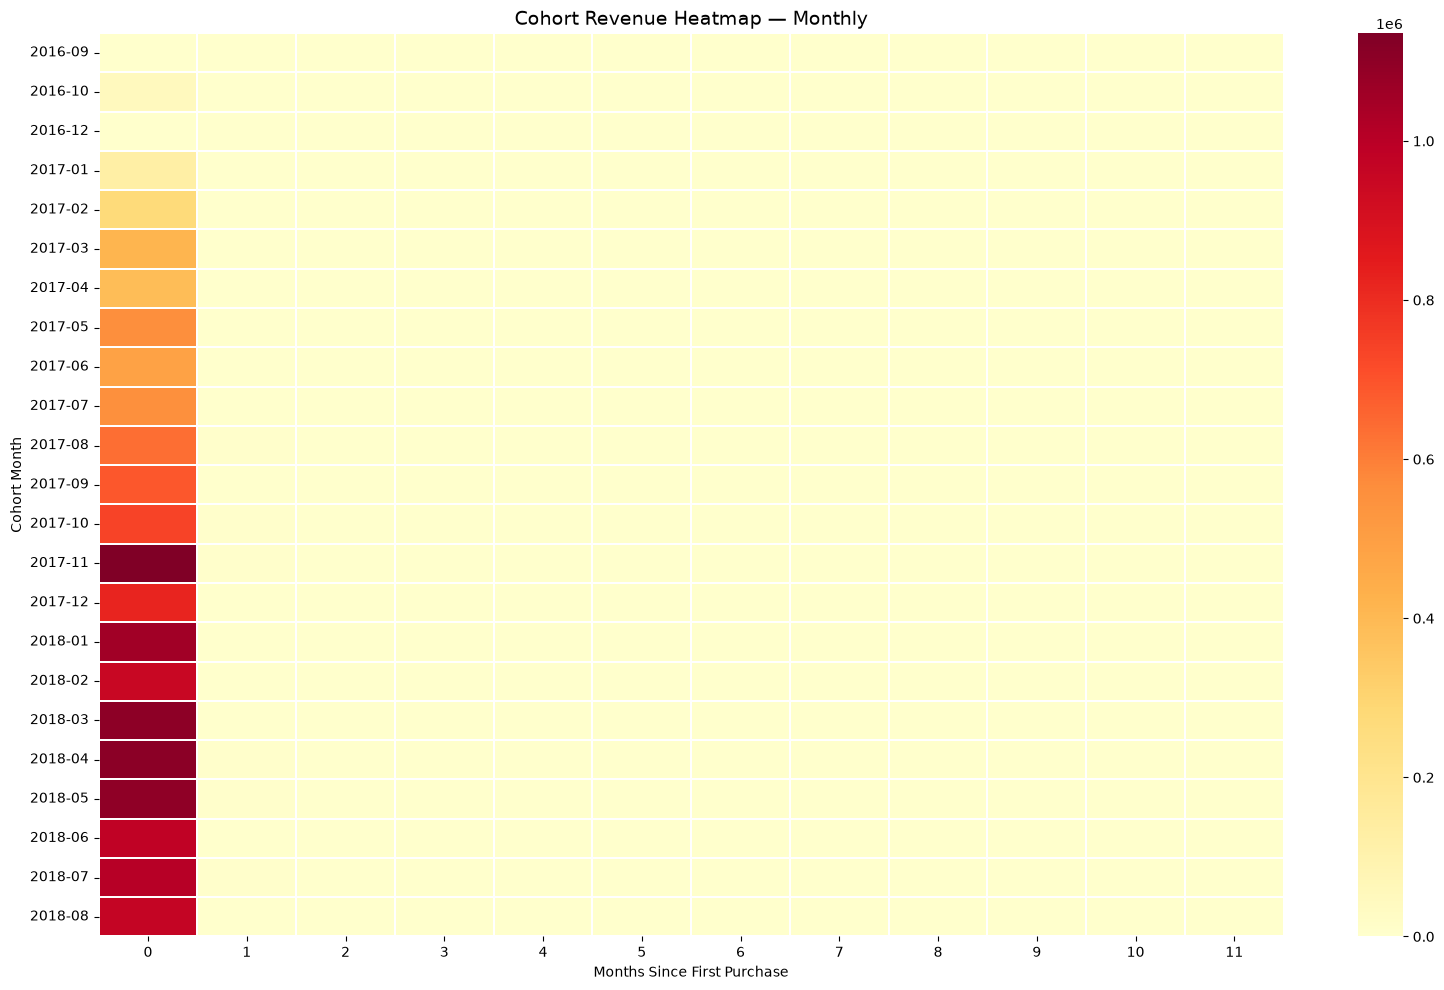

In [4]:
cohort_revenue = df.groupby(['cohort_month','months_since_first'])['payment_value'].sum().reset_index()

cohort_pivot = cohort_revenue.pivot(index='cohort_month', 
                                     columns='months_since_first', 
                                     values='payment_value').fillna(0)

plt.figure(figsize=(16, 10))
sns.heatmap(cohort_pivot.iloc[:, :12], annot=False, fmt='.0f',
            cmap='YlOrRd', linewidths=0.3)
plt.title('Cohort Revenue Heatmap — Monthly', fontsize=14)
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('../reports/03_cohort_revenue_heatmap.png', dpi=150)
plt.show()

In [5]:
# Avg order value per customer
customer_stats = df.groupby('customer_unique_id').agg(
    total_revenue    = ('payment_value', 'sum'),
    total_orders     = ('order_id',      'nunique'),
    first_purchase   = ('purchase_month','min'),
    last_purchase    = ('purchase_month','max')
).reset_index()

customer_stats['lifespan_months'] = (
    customer_stats['last_purchase'] - customer_stats['first_purchase']
).apply(lambda x: max(x.n, 1))

customer_stats['avg_order_value']    = customer_stats['total_revenue'] / customer_stats['total_orders']
customer_stats['purchase_frequency'] = customer_stats['total_orders'] / customer_stats['lifespan_months']
customer_stats['LTV']                = customer_stats['avg_order_value'] * customer_stats['purchase_frequency'] * customer_stats['lifespan_months']

print(f"Avg LTV : R$ {customer_stats['LTV'].mean():.2f}")
print(f"Med LTV : R$ {customer_stats['LTV'].median():.2f}")
print(f"Max LTV : R$ {customer_stats['LTV'].max():.2f}")

Avg LTV : R$ 165.20
Med LTV : R$ 107.78
Max LTV : R$ 13664.08


In [6]:
channel_seller = mql.merge(deals[['mql_id','seller_id']], on='mql_id', how='inner')
channel_seller = channel_seller[['seller_id','origin']].dropna()

items_channel = items[['order_id','seller_id']].merge(channel_seller, on='seller_id', how='inner')

df_channel = df.merge(items_channel[['order_id','origin']], on='order_id', how='left')

ltv_channel = df_channel.groupby('origin')['payment_value'].agg(['sum','mean','count']).reset_index()
ltv_channel.columns = ['origin','total_revenue','avg_order_value','total_orders']

# Merge CAC from previous notebook
cac_map = {
    'organic_search' : 18.45,
    'paid_search'    : 256.41,
    'social'         : 533.33,
    'direct_traffic' : 35.71,
    'referral'       : 125.00,
    'email'          : 666.67,
    'display'        : 3333.33
}

ltv_channel['CAC']        = ltv_channel['origin'].map(cac_map)
ltv_channel['LTV_CAC']    = (ltv_channel['avg_order_value'] / ltv_channel['CAC']).round(2)

clean_ltv = ltv_channel[ltv_channel['origin'].isin(cac_map.keys())]
print(clean_ltv[['origin','avg_order_value','CAC','LTV_CAC']].sort_values('LTV_CAC', ascending=False))

           origin  avg_order_value      CAC  LTV_CAC
3  organic_search       207.885726    18.45    11.27
0  direct_traffic       148.506278    35.71     4.16
6        referral       271.912895   125.00     2.18
5     paid_search       166.070924   256.41     0.65
2           email       384.565417   666.67     0.58
7          social       142.531857   533.33     0.27
1         display       172.564286  3333.33     0.05


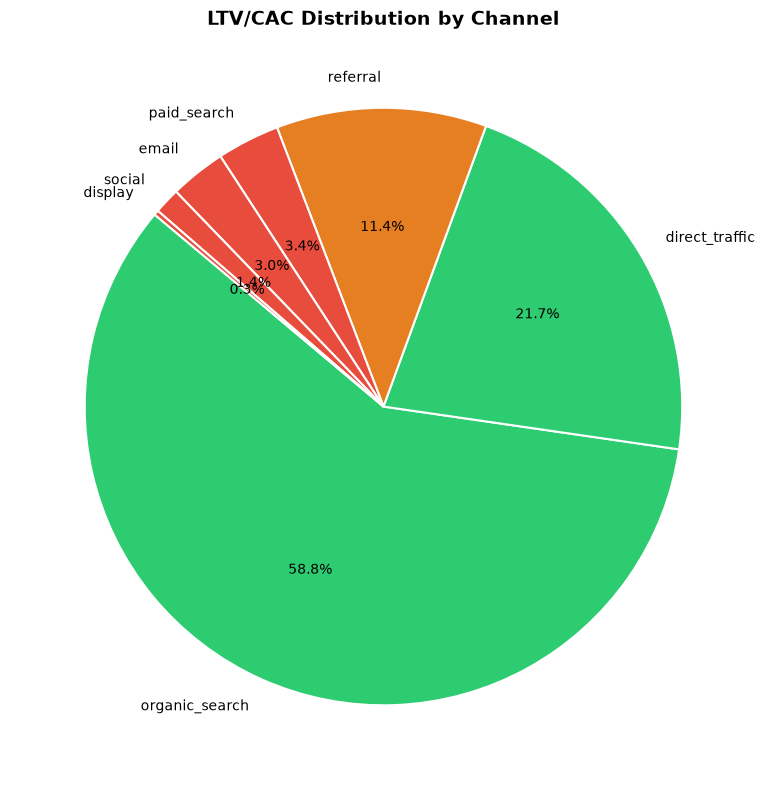

In [7]:
plt.figure(figsize=(8, 8))

colors = ['#2ecc71' if x >= 3 else '#e67e22' if x >= 1 else '#e74c3c' 
          for x in clean_ltv.sort_values('LTV_CAC', ascending=False)['LTV_CAC']]

plt.pie(
    clean_ltv.sort_values('LTV_CAC', ascending=False)['LTV_CAC'],
    labels=clean_ltv.sort_values('LTV_CAC', ascending=False)['origin'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('LTV/CAC Distribution by Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/03_ltv_cac_pie.png', dpi=150)
plt.show()